In [1]:
import jaxmapse
import classy
import numpy as np
import matplotlib.pyplot as plt
# Enable full LaTeX power
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
})

/home/marcobonici/miniconda3/lib/python3.12/site-packages/jaxmapse/__init__.py:82: UserWarning: Artifacts.toml not found at /home/marcobonici/miniconda3/lib/python3.12/site-packages/Artifacts.toml
  warnings.warn(f"Artifacts.toml not found at {_ARTIFACTS_TOML}")


In [2]:
import jax.numpy as jnp

In [3]:
emu = jaxmapse.trained_emulators["mnuw0wacdm_class"]

In [4]:
k = emu.linear_pmm.k_grid

In [5]:
params = np.array([0.29888 ,  3.044, 0.9665, 67.1734 , 0.022773 , 0.15  ,   0.06 , -1.5    , 0.42523])

cosmo = jaxmapse.w0waCDMCosmology(
        ln10As=params[1], 
        ns=params[2], 
        h=params[3] / 100.0,
        omega_b=params[4], 
        omega_c=params[5], 
        m_nu=params[6],
        w0=params[7], 
        wa=params[8], 
    )
D = cosmo.D_z(params[0])

In [6]:
emu.linear_pkcb.out_minmax.shape

(17, 2)

In [7]:
# Linear spectra only. Do not call emu.get_Pk(...) here: that evaluates the Boost component,
# whose k-grid does not match the 300-point PCA linear spectra in this artifact.
Pcb = emu.get_linear_pkcb(params[1:], params[0], D)
Pmm = emu.get_linear_pmm(params[1:], params[0], D)


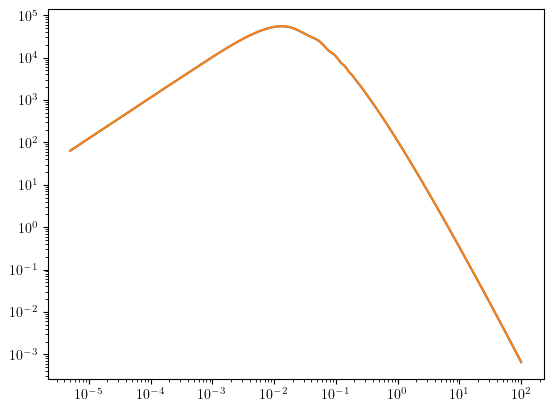

In [8]:
plt.loglog(k, Pmm)
plt.loglog(k, Pcb)

In [9]:
z = params[0]
h = params[3] / 100.0

cosmo_params = {
    "output": "mPk",
    "non_linear": "halofit",
    "P_k_max_h/Mpc": 50.0 / h,
    "z_pk": "0.0,5.",
    "h": h,
    "omega_b": params[4],
    "omega_cdm": params[5],
    "ln10^{10}A_s": params[1],
    "n_s": params[2],
    "tau_reio": 0.0568,
    "N_ur": 2.033,
    "N_ncdm": 1,
    "m_ncdm": params[6],
    "use_ppf": "yes",
    "w0_fld": params[7],
    "wa_fld": params[8],
    "fluid_equation_of_state": "CLP",
    "cs2_fld": 1.0,
    "Omega_Lambda": 0.0,
    "Omega_scf": 0.0,
    "halofit_min_k_max": 1000.0,
}

# =============================================================================
# OPTIMIZED k-GRID
# =============================================================================
K_MIN = 1e-5
K_BAO_START = 1e-2
K_BAO_END = 0.5
K_MAX = 20.0

# 1. Sparse low-k tail (smooth, linear in log-log)
_k_low  = np.geomspace(K_MIN, K_BAO_START, 15)

# 2. Dense BAO region (highly oscillatory)
_k_mid  = np.geomspace(K_BAO_START, K_BAO_END, 50)

# 3. Sparse high-k tail (smooth damping)
_k_high = np.geomspace(K_BAO_END, K_MAX, 15)

# Concatenate, dropping the overlapping boundary points [:-1]
k_grid = np.concatenate((_k_low[:-1], _k_mid[:-1], _k_high))

cosmo = classy.Class()
cosmo.set(cosmo_params)
cosmo.compute()

# P(k) in Mpc^3 units (k in Mpc^-1)
pk_lin_mm = np.array([cosmo.pk_lin(ki, z) for ki in k])
pk_lin_cb = np.array([cosmo.pk_cb_lin(ki, z) for ki in k])
pk_nl_mm = np.array([cosmo.pk(ki, z) for ki in k])

cosmo.struct_cleanup()
cosmo.empty()

DEBUG_HALOFIT_BG: tau=1.338378e+04, Omega_m=3.843239e-01, Omega_v=6.155959e-01, w=-1.500000e+00, fnu=0.000000e+00
DEBUG_HALOFIT: k=3.544233e-01, P_linaa=3.467921e+00, P_quasi=2.382639e+00, beta=1.528622e+00, alpha_coef=1.297429e+00
DEBUG_HALOFIT: k=3.544233e-01, P_quasi=1.056382e+03, P_halo=2.680215e+03, P_nl=3.736597e+03
DEBUG_HALOFIT_BG: tau=1.338378e+04, Omega_m=3.843239e-01, Omega_v=6.155959e-01, w=-1.500000e+00, fnu=3.714751e-03
DEBUG_HALOFIT: k=3.544233e-01, P_linaa=3.561537e+00, P_quasi=2.419574e+00, beta=1.533062e+00, alpha_coef=1.298495e+00
DEBUG_HALOFIT: k=3.544233e-01, P_quasi=1.072758e+03, P_halo=2.666047e+03, P_nl=3.738805e+03
DEBUG_HALOFIT_BG: tau=1.327252e+04, Omega_m=4.108030e-01, Omega_v=5.891090e-01, w=-1.489640e+00, fnu=0.000000e+00
DEBUG_HALOFIT: k=3.544233e-01, P_linaa=3.365948e+00, P_quasi=2.318957e+00, beta=1.517670e+00, alpha_coef=1.295841e+00
DEBUG_HALOFIT: k=3.544233e-01, P_quasi=1.028148e+03, P_halo=2.571968e+03, P_nl=3.600115e+03
DEBUG_HALOFIT_BG: tau=1.3272

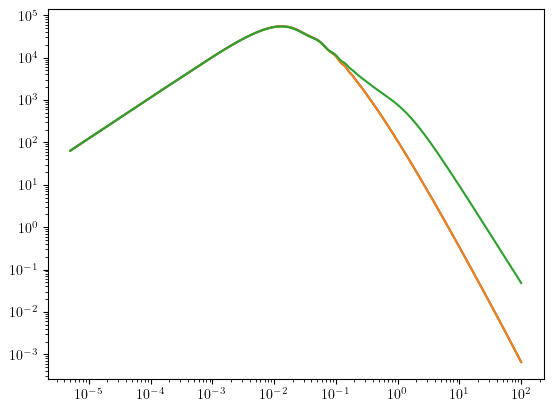

In [10]:
plt.loglog(k, pk_lin_cb)
plt.loglog(k, pk_lin_mm)
plt.loglog(k, pk_nl_mm)

Text(0.5, 0, '$k \\ [1/\\mathrm{Mpc}]$')

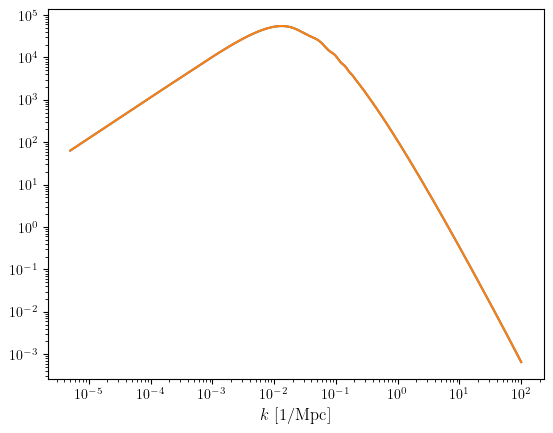

In [11]:
plt.loglog(k, pk_lin_cb)
plt.loglog(k, Pcb)
plt.xlabel(r'$k \ [1/\mathrm{Mpc}]$', fontsize=12)

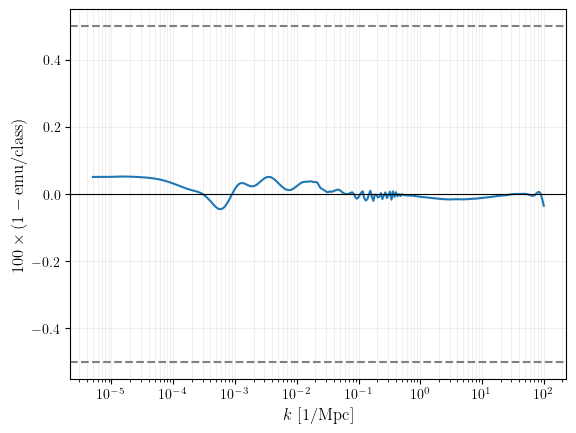

In [12]:
plt.plot(k, 100 * (1 - pk_lin_cb / Pcb))

# Axis Labels using LaTeX
plt.xlabel(r'$k \ [1/\mathrm{Mpc}]$', fontsize=12)
plt.ylabel(r'$100 \times (1 - \mathrm{emu}/\mathrm{class})$', fontsize=12)

# Scales and Reference Lines
plt.xscale('log')
plt.axhline(0, color='black', linestyle='-', linewidth=0.8) # Baseline
plt.axhline(0.5, color='gray', linestyle='--')             # +0.5% threshold
plt.axhline(-0.5, color='gray', linestyle='--')            # -0.5% threshold

plt.grid(True, which="both", ls="-", alpha=0.2)
plt.show()

Text(0, 0.5, '$100 \\times (1 - \\mathrm{emu}/\\mathrm{class})$')

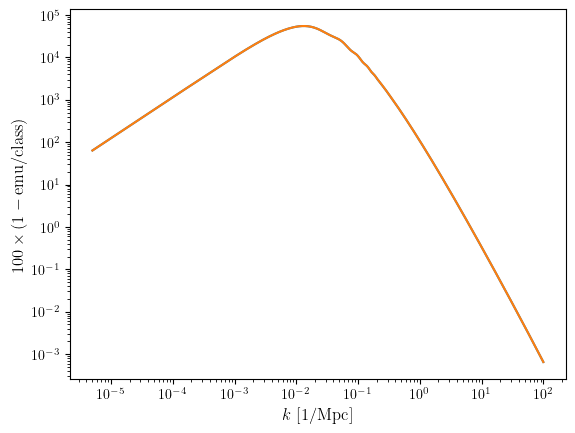

In [13]:
plt.loglog(k, pk_lin_mm)
plt.loglog(k, Pmm)
plt.xlabel(r'$k \ [1/\mathrm{Mpc}]$', fontsize=12)
plt.ylabel(r'$100 \times (1 - \mathrm{emu}/\mathrm{class})$', fontsize=12)

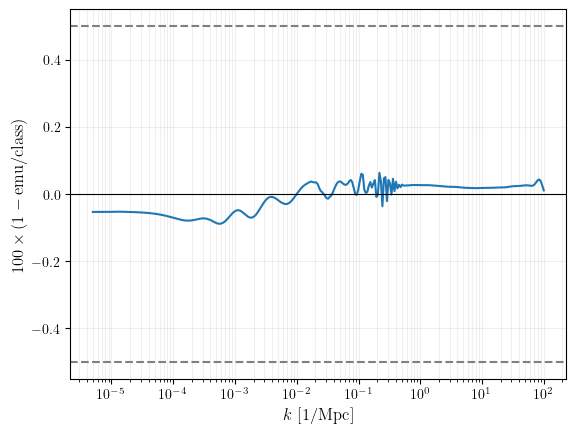

In [14]:
plt.plot(k, 100 * (1 - pk_lin_mm / Pmm))

# Axis Labels using LaTeX
plt.xlabel(r'$k \ [1/\mathrm{Mpc}]$', fontsize=12)
plt.ylabel(r'$100 \times (1 - \mathrm{emu}/\mathrm{class})$', fontsize=12)

# Scales and Reference Lines
plt.xscale('log')
plt.axhline(0, color='black', linestyle='-', linewidth=0.8) # Baseline
plt.axhline(0.5, color='gray', linestyle='--')             # +0.5% threshold
plt.axhline(-0.5, color='gray', linestyle='--')            # -0.5% threshold

plt.grid(True, which="both", ls="-", alpha=0.2)
plt.show()